Predicción del nivel de estrés

🌍 Contexto

Los niveles de estrés afectan directamente a la salud física y mental.

En este proyecto, trabajarás como si fueras parte del equipo de desarrollo de un sistema de monitoreo de estrés para deportistas de alto rendimiento o trabajadores en ambientes exigentes.

Se te ha encomendado diseñar un clasificador que, a partir de tres medidas fisiológicas, pueda predecir el nivel de estrés de una persona.

Para ello, deberás simular datos realistas, entrenar un modelo de aprendizaje automático y visualizar los resultados.



🎯 Objetivos

Simular datos fisiológicos (ritmo cardíaco, nivel de cortisol y conductancia de la piel).

Clasificar el nivel de estrés de las personas como:

🟢 Bajo, 🟠 Moderado o 🔴 Alto.

Entrenar un clasificador Random Forest.

Evaluar el rendimiento del modelo.

Realizar predicciones personalizadas.

Visualizar los datos y resultados con gráficos interpretables.



🛠️ Requisitos Técnicos

Debes usar:

NumPy para generar datos.

Pandas para manipular estructuras.

matplotlib.pyplot para visualizar.

sklearn para entrenamiento del modelo y métricas.

Programación orientada a objetos (clases bien definidas).



👨‍🔬 Parte 1: Clase para representar individuos

Crea una clase llamada Individual con los siguientes atributos:

Ritmo cardíaco (heart_rate) en pulsaciones por minuto.

Nivel de cortisol (cortisol_level) en µg/dL.

Conductancia de la piel (skin_conductance) en µS.

Nivel de estrés (stress_level): cadena de texto ('Bajo', 'Moderado' o 'Alto').

Incluye un método to_vector() que devuelva solo las tres primeras variables como lista.



🧪 Parte 2: Simulador de datos

Crea una clase StressDataGenerator que genere una lista de objetos Individual con valores aleatorios realistas:

Ritmo cardíaco: media 75, desviación estándar 15.

Cortisol: media 12, desviación estándar 4.

Conductancia: media 5, desviación estándar 1.5.

Clasifica los individuos según estas reglas:

🔴 Alto: si cualquiera de las tres medidas supera estos umbrales:

Ritmo cardíaco > 90

Cortisol > 18

Conductancia > 6.5

🟠 Moderado: si alguna supera:

Ritmo cardíaco > 70

Cortisol > 10

Conductancia > 4.5

pero no cumple los criterios de "Alto".

🟢 Bajo: si ninguna medida supera esos valores.



🤖 Parte 3: Clasificador con Random Forest

Crea una clase StressClassifier con los métodos:

fit(individuals) → entrena el modelo con datos.

predict(heart_rate, cortisol, conductance) → devuelve el nivel de estrés estimado.

evaluate(test_data) → imprime matriz de confusión e informe de clasificación.



🔍 Parte 4: Ejecución completa del análisis

Crea una clase llamada StressAnalysisExample que se encargue de ejecutar todo el flujo del proyecto. 

Esta clase debe implementar un método run() que realice las siguientes tareas:

Generación de datos:

Genera 300 individuos simulados usando la clase StressDataGenerator.

Entrenamiento y evaluación del modelo:

Divide los datos en dos subconjuntos: 70% para entrenamiento y 30% para prueba.

Entrena un clasificador usando la clase StressClassifier.

Evalúa el rendimiento del modelo mostrando:

La matriz de confusión.

El informe de clasificación con precisión, recall y f1-score.

Predicción personalizada:

Utiliza el modelo entrenado para predecir el nivel de estrés de un individuo con las siguientes características:

Ritmo cardíaco: 95

Cortisol: 20

Conductancia: 7

Muestra por pantalla la predicción realizada.

Visualización de los datos:

Convierte los datos generados en un DataFrame de pandas.

Crea un gráfico de dispersión con matplotlib:

Eje X: nivel de cortisol.

Eje Y: ritmo cardíaco.

Color de los puntos según el nivel de estrés:

🟢 Verde → Bajo

🟠 Naranja → Moderado

🔴 Rojo → Alto

Agrega título, leyenda y cuadrícula para facilitar la interpretación visual.





✅ Ejemplo de uso

example = StressAnalysisExample()

example.run()


Salida esperada

📊 Matriz de confusión:

[[33  0  0]

 [ 0  2  1]
 
 [ 0  0 54]]
 
 
📝 Informe de clasificación:
              precision    recall  f1-score   support
 
        Alto       1.00      1.00      1.00        33
        
        Bajo       1.00      0.67      0.80         3
        
    Moderado       0.98      1.00      0.99        54
 
    accuracy                           0.99        90
    
   macro avg       0.99      0.89      0.93        90
   
weighted avg       0.99      0.99      0.99        90
 
 
🧠 Predicción para individuo personalizado:

  Ritmo cardíaco: 95, Cortisol: 20, Conductancia: 7
  
  → Nivel estimado de estrés: Alto
















Practicar con numpy para generar datos, el algoritmo de Random Forest para realizar predicciones sobre el nivel de estrés de una persona y pandas con matplotlib para graficar los datos obtenidos.

# Solucion:

Generando datos sintéticos de 300 pacientes...
----------------------------------------
Evaluando modelo con el conjunto de prueba...

📊 Matriz de confusión:
[[31  0  0]
 [ 0  1  3]
 [ 1  0 54]]

📝 Informe de clasificación:
              precision    recall  f1-score   support

        Alto       0.97      1.00      0.98        31
        Bajo       1.00      0.25      0.40         4
    Moderado       0.95      0.98      0.96        55

    accuracy                           0.96        90
   macro avg       0.97      0.74      0.78        90
weighted avg       0.96      0.96      0.95        90

----------------------------------------
🧠 Predicción para individuo personalizado:
  Ritmo cardíaco: 95, Cortisol: 20, Conductancia: 7
  → Nivel estimado de estrés: Alto

📈 Generando gráfico...


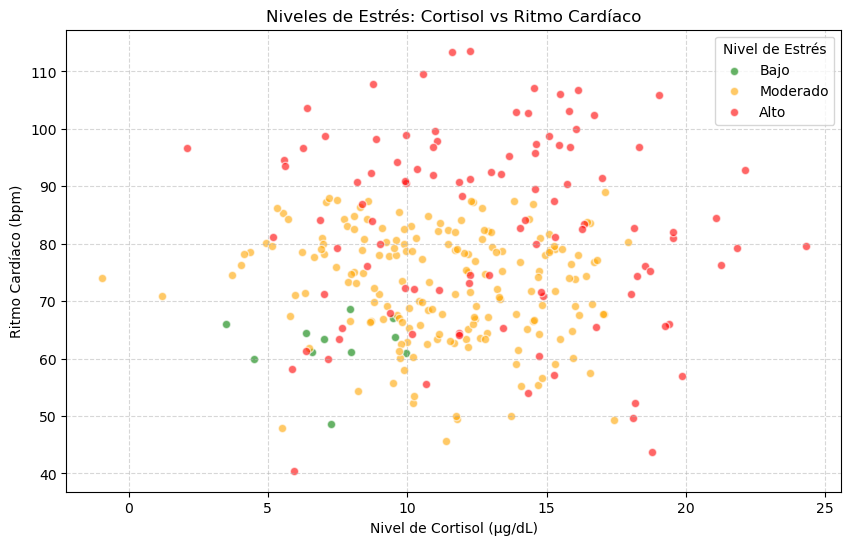

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


class Individual:
    def __init__(self, heart_rate, cortisol_level, skin_conductance, stress_level=None):
        self.heart_rate = heart_rate
        self.cortisol_level = cortisol_level
        self.skin_conductance = skin_conductance
        self.stress_level = stress_level

    def to_vector(self):
        """Devuelve las características fisiológicas como lista numérica."""
        return [self.heart_rate, self.cortisol_level, self.skin_conductance]


class StressDataGenerator:
    def __init__(self, n_samples=300, seed=42):
        self.n_samples = n_samples
        self.seed = seed
        np.random.seed(seed) # Para reproducibilidad

    def generate(self):
        individuals = []
        for _ in range(self.n_samples):

            hr = np.random.normal(75, 15)
            cort = np.random.normal(12, 4)
            cond = np.random.normal(5, 1.5)


            if hr > 90 or cort > 18 or cond > 6.5:
                level = 'Alto'
            elif hr > 70 or cort > 10 or cond > 4.5:
                level = 'Moderado'
            else:
                level = 'Bajo'

            individuals.append(Individual(hr, cort, cond, level))
        
        return individuals


class StressClassifier:
    def __init__(self):

        self.model = RandomForestClassifier(n_estimators=100, random_state=42)

    def fit(self, individuals):
        """Entrena el modelo."""
        X = [ind.to_vector() for ind in individuals]
        y = [ind.stress_level for ind in individuals]
        self.model.fit(X, y)

    def predict(self, heart_rate, cortisol_level, skin_conductance):
        """Predice el nivel de estrés para nuevos valores."""
        features = [[heart_rate, cortisol_level, skin_conductance]]
        return self.model.predict(features)[0]

    def evaluate(self, individuals):
        """Genera métricas de rendimiento."""
        X_test = [ind.to_vector() for ind in individuals]
        y_true = [ind.stress_level for ind in individuals]
        y_pred = self.model.predict(X_test)

        print("\n📊 Matriz de confusión:")
        print(confusion_matrix(y_true, y_pred))
        
        print("\n📝 Informe de clasificación:")
        print(classification_report(y_true, y_pred))


class StressAnalysisExample:
    def run(self):

        print("Generando datos sintéticos de 300 pacientes...")
        generator = StressDataGenerator(n_samples=300)
        dataset = generator.generate()


        train_data, test_data = train_test_split(dataset, test_size=0.3, random_state=42)


        classifier = StressClassifier()
        classifier.fit(train_data)


        print("-" * 40)
        print("Evaluando modelo con el conjunto de prueba...")
        classifier.evaluate(test_data)


        print("-" * 40)
        custom_hr, custom_cort, custom_cond = 95, 20, 7
        prediction = classifier.predict(custom_hr, custom_cort, custom_cond)
        
        print("🧠 Predicción para individuo personalizado:")
        print(f"  Ritmo cardíaco: {custom_hr}, Cortisol: {custom_cort}, Conductancia: {custom_cond}")
        print(f"  → Nivel estimado de estrés: {prediction}")


        self.visualize_data(dataset)

    def visualize_data(self, individuals):
        """Visualiza Coritsol vs Ritmo Cardíaco coloreado por estrés."""

        data_dicts = [
            {
                'Cortisol': ind.cortisol_level, 
                'HeartRate': ind.heart_rate, 
                'Stress': ind.stress_level
            } 
            for ind in individuals
        ]
        df = pd.DataFrame(data_dicts)

        plt.figure(figsize=(10, 6))
        

        colors = {'Bajo': 'green', 'Moderado': 'orange', 'Alto': 'red'}
        

        for stress_type, color in colors.items():
            subset = df[df['Stress'] == stress_type]
            plt.scatter(
                subset['Cortisol'], 
                subset['HeartRate'], 
                c=color, 
                label=stress_type, 
                alpha=0.6, 
                edgecolors='w'
            )

        plt.title('Niveles de Estrés: Cortisol vs Ritmo Cardíaco')
        plt.xlabel('Nivel de Cortisol (µg/dL)')
        plt.ylabel('Ritmo Cardíaco (bpm)')
        plt.legend(title="Nivel de Estrés")
        plt.grid(True, linestyle='--', alpha=0.5)
        
        print("\n📈 Generando gráfico...")
        plt.show()


if __name__ == "__main__":
    example = StressAnalysisExample()
    example.run()

Casos de prueba

Suspenso: 0, Aprobado: 3 de 3 pruebas

test_consistent_classification

test_model_accuracy_on_train

test_prediction_output